<h1 align="center" style="color:red;">Assignment 8: Probability Concepts
(Questions)</h1>

---

<h1 align="center" style="color: blue;">Part 1: Handling missing values & Basic
concepts in Probability</h1>

---
# Load the Dataset and Answer the Following Questions:
1. How many null values are there in each column?
    - 1.1. Replace the null value of column "wheelbase" with the max value of the same
    - column.
    - 1.2. Replace the null value of column "carwidth" with the Min value of the same column.
    - 1.3. Use Linear Interpolation to change the null value of column "carheight"
    - 1.4. Replace the null value of column "enginesize" with the mod of the same column.
2. What is the Probability that a Car is Sedan ?
3. What is the Probability that a car is Sedan and works with gas ?
4. What is the probability that a car is Sedan given it is a gas fuel type?
5. Given that the car height is higer than 65, find the probability that the car engin size is
greater than 130?
### Import necessary libraries, load the 'Cars.csv' dataset, display a data sample, determine dataset dimensions, and determine the summary statistics for quantitative and qualtitative columns.

In [1]:
#import all required libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
import math

In [2]:
#Read and show the file
df = pd.read_csv("Cars.csv")
df.head()

,carname,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,carwidth,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,...,130.0,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,...,130.0,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,...,152.0,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,...,109.0,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,audi 100ls,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,...,136.0,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [3]:
#Determine the dataset dimension
df.shape

(205, 24)

In [4]:
#use describe function for qualatitve columns
df.describe()

,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
count,194.000000,205.000000,185.000000,190.000000,205.000000,185.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,98.669588,174.049268,65.932973,53.738947,2555.565854,124.081081,3.329756,3.255415,10.142537,104.117073,5125.121951,25.219512,30.751220,13276.710571
std,5.934168,12.337289,2.113143,2.470452,520.680204,38.528771,0.270844,0.313597,3.972040,39.544167,476.985643,6.542142,6.886443,7988.852332
min,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,94.500000,166.300000,64.200000,52.000000,2145.000000,97.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7788.000000
50%,97.000000,173.200000,65.500000,54.100000,2414.000000,110.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,101.800000,183.100000,66.600000,55.575000,2935.000000,141.000000,3.580000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16503.000000
max,120.900000,208.100000,72.300000,59.800000,4066.000000,308.000000,3.940000,4.170000,23.000000,288.000000,6600.000000,49.000000,54.000000,45400.000000


In [5]:
#use describe function for quantitative columns
df.describe(include=["object", "category"])

/tmp/ipykernel_1147412/4274538952.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include=["object", "category"])


,carname,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,enginetype,cylindernumber,fuelsystem
count,205,205,205,205,205,205,205,205,205,205
unique,147,2,2,2,5,3,2,7,7,8
top,peugeot 504,gas,std,four,sedan,fwd,front,ohc,four,mpfi
freq,6,185,168,115,96,120,202,148,159,94


## Q1: How many null values are there in each column?

In [6]:
#How many null values for each column?
df.isna().sum()

carname              0
fueltype             0
aspiration           0
doornumber           0
carbody              0
drivewheel           0
enginelocation       0
wheelbase           11
carlength            0
carwidth            20
carheight           15
curbweight           0
enginetype           0
cylindernumber       0
enginesize          20
fuelsystem           0
boreratio            0
stroke               0
compressionratio     0
horsepower           0
peakrpm              0
citympg              0
highwaympg           0
price                0
dtype: int64

## Q1_1: Replace the null value of column "wheelbase" with the max value of the same column

In [7]:
df["wheelbase"] = df["wheelbase"].fillna(df["wheelbase"].max())

## Q1_2: Replace the null value of column "carwidth" with the Min value of the same column

In [8]:
df["carwidth"] = df["carwidth"].fillna(df["carwidth"].min())

## Q1_3: Use Linear Interpolation to change the null value of column "carheight"

In [9]:
df["carheight"] = df["carheight"].interpolate(method="linear")

## Q1_4: Replace the null value of column "enginesize" with the mod of the same column and check how many null values we have

In [10]:
df["enginesize"] = df["enginesize"].fillna(df["enginesize"].mode()[0])
df.isna().sum()

carname             0
fueltype            0
aspiration          0
doornumber          0
carbody             0
drivewheel          0
enginelocation      0
wheelbase           0
carlength           0
carwidth            0
carheight           0
curbweight          0
enginetype          0
cylindernumber      0
enginesize          0
fuelsystem          0
boreratio           0
stroke              0
compressionratio    0
horsepower          0
peakrpm             0
citympg             0
highwaympg          0
price               0
dtype: int64

## Q2: What is the Probability that the Car is Sedan ? (1 mark)

In [11]:
(df["carbody"] == "sedan").mean()

np.float64(0.4682926829268293)

## Q3: What is the Probability that the car is Sedan and works with gas ?

In [12]:
((df["carbody"] == "sedan") & (df["fueltype"] == "gas")).mean()

np.float64(0.3951219512195122)

## Q4:What is the probability that a car is Sedan given it is a gas fuel type?


In [13]:
(df[df["carbody"] == "sedan"]["fueltype"] == "gas").mean()

np.float64(0.84375)

## Q5: Given that the car height is higer than 50, find the probability that the car engin size is greater than 130?

In [14]:
(df[df["carheight"] > 50]["enginesize"] > 130).mean()

np.float64(0.2916666666666667)

---

<h1 align="center" style="color: blue;">Part 2: Probability Functions</h1>

---

## Q6: Load dataset 'students.csv' and show first rows, shape, and compute the skewness.

In [15]:
df = pd.read_csv("students.csv")
df.head()

,stud.id,name,gender,age,height,weight,religion,nc.score,semester,major,minor,score1,score2,online.tutorial,graduated,salary
0,833917,"Gonzales, Christina",Female,19,160,64.8,Muslim,1.91,1st,Political Science,Social Sciences,NaN,NaN,0,0,NaN
1,898539,"Lozano, T'Hani",Female,19,172,73.0,Other,1.56,2nd,Social Sciences,Mathematics and Statistics,NaN,NaN,0,0,NaN
2,379678,"Williams, Hanh",Female,22,168,70.6,Protestant,1.24,3rd,Social Sciences,Mathematics and Statistics,45.0,46.0,0,0,NaN
3,807564,"Nem, Denzel",Male,19,183,79.7,Other,1.37,2nd,Environmental Sciences,Mathematics and Statistics,NaN,NaN,0,0,NaN
4,383291,"Powell, Heather",Female,21,175,71.4,Catholic,1.46,1st,Environmental Sciences,Mathematics and Statistics,NaN,NaN,0,0,NaN


In [16]:
df.shape

(8239, 16)

In [17]:
df.skew(numeric_only=True)

stud.id            0.018612
age                4.427823
height            -0.009244
weight             0.651004
nc.score           0.446834
score1            -0.318819
score2            -0.304878
online.tutorial    0.467502
graduated          1.403900
salary             0.273835
dtype: float64

## Q7: What is the probability that the salary is greater than 20000 and less than 30000 ?
To answer this question, you should do the following:
1. Identify the distribution by
    - Plotting Histogram
    - calculate the skewness
    - Which distribution does this data follow?
2. Compute mean and std
3. Convert to Z-scores
4. Use CDF difference with the use of the right distribution function from scipy.stats

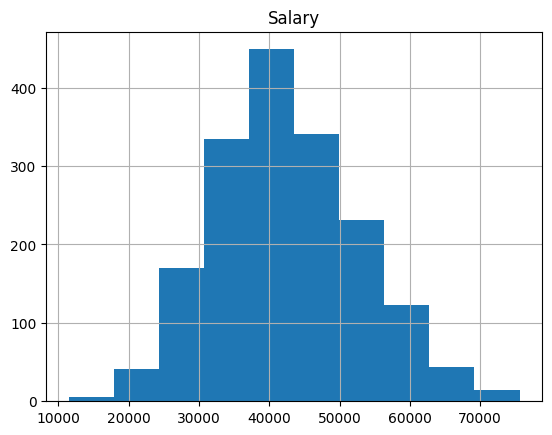

In [18]:
#1.1) Plotting Histogram
df["salary"].hist()
plt.title("Salary")
plt.show()

In [19]:
#1.2) calculate the skewness
df["salary"].skew()

np.float64(0.273835141614412)

**Answer: The distrbuiton of the `salary` is `normal distribution`**

In [20]:
#2) Compute mean and std 
salary_mean = df["salary"].mean()
salary_std = df["salary"].std()

In [21]:
#3) Convert to Z-scores
z_score_20k = (20000 - salary_mean) / salary_std 
z_score_30k = (30000 - salary_mean) / salary_std

In [22]:
# 4) Calculate the probability
probability = stats.norm.cdf(z_score_30k) - stats.norm.cdf(z_score_20k)
probability

np.float64(0.09814325462173663)

## Q8: A factory produces 200 chips with defect rate 8%. Answer the following questions:
1. What is the distribution name of this problem, based on the following questions ?
2. What is the probability of getting exactly 14 defective chips ?
3. At least 14 defective ?
4. At most 15 defective ?
5. Expected defects and standard deviation

You should use the right distribution function from scipy.stats to proceed with the answers

1- The distribution name of this problem is `binomial distribution`

In [23]:
# 2)
stats.binom.pmf(14, 200, 0.08)

np.float64(0.0954115649226197)

In [24]:
# 3)
1 - stats.binom.cdf(13, 200, 0.08)

np.float64(0.7357078859493741)

In [25]:
# 4)
stats.binom.cdf(15, 200, 0.08)

np.float64(0.4625822359332888)

In [26]:
# 5)
expected_defects = 200 * 0.08
stdev = math.sqrt(200 * 0.08 * 0.92)

print("Expected defects:", expected_defects)
print("Standard deviaton:", stdev)

Expected defects: 16.0
Standard deviaton: 3.8366652186501757


In [29]:
df_mean = df["salary"].mean()
df_std = df["salary"].std()

z_30000 = (30000 - df_mean) / df_std
z_20000 = (20000 - df_mean) / df_std

stats.norm.cdf(z_30000) - stats.norm.cdf(z_20000)

np.float64(0.09814325462173663)